In [2]:
# base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score,
)

# models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
import joblib

In [3]:
warnings.filterwarnings('ignore')

df = pd.read_parquet("data/flight.parquet", engine="pyarrow")
df

,flight,payload,route,altitude_preset,date,time_day,duration_s,total_distance_m,wind_speed_mean,wind_speed_std,...,velocity_mag_max,acceleration_mag_mean,acceleration_mag_std,battery_voltage_mean,battery_voltage_min,max_height_agl,final_height_agl,energy_consumed_Wh,battery_needed_mAh,landing_offset_flag
0,1,0.0,R5,25,2019-04-07,10:13,200.70,549.065984,3.898058,1.952675,...,6.261616,9.842870,0.466372,22.070134,21.228519,26.257755,-0.994409,21.769975,1000.743935,False
1,2,0.0,R5,50,2019-04-07,10:23,271.20,666.615556,3.522941,2.159456,...,7.676739,9.881874,0.628406,21.527547,20.125463,52.637988,0.589477,25.366627,1205.255874,False
2,3,0.0,R5,25,2019-04-07,10:33,180.10,577.009957,4.581182,3.335733,...,7.213987,9.902090,0.545290,22.330305,19.943916,24.660462,0.106140,17.094392,789.073853,False
3,4,0.0,R5,25,2019-04-07,10:48,171.00,562.802357,4.596319,3.438072,...,9.425537,9.900368,0.559073,21.950616,20.365856,25.580572,0.416669,14.690038,687.813976,False
4,5,0.0,R2,25,2019-04-07,11:05,217.00,470.978276,3.333910,2.247522,...,4.900079,9.817243,0.341981,21.519937,18.923494,24.323036,-0.924901,19.019928,920.070980,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,275,500.0,R1,25,2019-10-24,9:05,149.40,518.231162,4.139878,3.885389,...,8.788151,9.850903,0.420902,22.056616,20.332052,21.959932,-3.264891,16.295811,760.480643,False
205,276,500.0,R1,25,2019-10-24,9:32,147.90,517.758034,4.392581,4.332293,...,10.553163,9.862172,0.471081,21.492353,19.788662,22.542598,1.293232,15.392088,738.620356,False
206,277,500.0,R1,25,2019-10-24,9:45,134.81,517.677109,5.524651,4.029744,...,10.579715,9.847796,0.529103,21.908016,19.352947,24.289124,-0.286362,15.531389,741.451254,False
207,278,500.0,R7,25-50-100-25,2019-10-24,10:00,186.39,545.413261,4.686967,3.826570,...,10.376503,9.829065,0.456918,22.394109,20.407175,95.041887,-0.457578,18.922540,887.198699,False


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   flight                 209 non-null    int64   
 1   payload                209 non-null    float64 
 2   route                  209 non-null    category
 3   altitude_preset        209 non-null    string  
 4   date                   209 non-null    str     
 5   time_day               209 non-null    str     
 6   duration_s             209 non-null    float64 
 7   total_distance_m       209 non-null    float64 
 8   wind_speed_mean        209 non-null    float64 
 9   wind_speed_std         209 non-null    float64 
 10  wind_x_mean            209 non-null    float64 
 11  wind_y_mean            209 non-null    float64 
 12  speed_mean             209 non-null    float64 
 13  speed_max              209 non-null    float64 
 14  velocity_mag_mean      209 non-null    float64 
 15  

In [8]:
artifacts = joblib.load('models/duration_s_model.pkl')

time_model = artifacts['model']
time_feature = artifacts['features']

time_pred = time_model.predict(df[time_feature])

temp = df.copy()
temp['time_pred'] = time_pred
temp

,flight,payload,route,altitude_preset,date,time_day,duration_s,total_distance_m,wind_speed_mean,wind_speed_std,...,acceleration_mag_mean,acceleration_mag_std,battery_voltage_mean,battery_voltage_min,max_height_agl,final_height_agl,energy_consumed_Wh,battery_needed_mAh,landing_offset_flag,time_pred
0,1,0.0,R5,25,2019-04-07,10:13,200.70,549.065984,3.898058,1.952675,...,9.842870,0.466372,22.070134,21.228519,26.257755,-0.994409,21.769975,1000.743935,False,215.027865
1,2,0.0,R5,50,2019-04-07,10:23,271.20,666.615556,3.522941,2.159456,...,9.881874,0.628406,21.527547,20.125463,52.637988,0.589477,25.366627,1205.255874,False,215.027865
2,3,0.0,R5,25,2019-04-07,10:33,180.10,577.009957,4.581182,3.335733,...,9.902090,0.545290,22.330305,19.943916,24.660462,0.106140,17.094392,789.073853,False,215.027865
3,4,0.0,R5,25,2019-04-07,10:48,171.00,562.802357,4.596319,3.438072,...,9.900368,0.559073,21.950616,20.365856,25.580572,0.416669,14.690038,687.813976,False,215.027865
4,5,0.0,R2,25,2019-04-07,11:05,217.00,470.978276,3.333910,2.247522,...,9.817243,0.341981,21.519937,18.923494,24.323036,-0.924901,19.019928,920.070980,False,215.027865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,275,500.0,R1,25,2019-10-24,9:05,149.40,518.231162,4.139878,3.885389,...,9.850903,0.420902,22.056616,20.332052,21.959932,-3.264891,16.295811,760.480643,False,214.527261
205,276,500.0,R1,25,2019-10-24,9:32,147.90,517.758034,4.392581,4.332293,...,9.862172,0.471081,21.492353,19.788662,22.542598,1.293232,15.392088,738.620356,False,214.527261
206,277,500.0,R1,25,2019-10-24,9:45,134.81,517.677109,5.524651,4.029744,...,9.847796,0.529103,21.908016,19.352947,24.289124,-0.286362,15.531389,741.451254,False,214.527261
207,278,500.0,R7,25-50-100-25,2019-10-24,10:00,186.39,545.413261,4.686967,3.826570,...,9.829065,0.456918,22.394109,20.407175,95.041887,-0.457578,18.922540,887.198699,False,214.527261


In [9]:
main_feature_cols = [
    'total_distance_m',
    'max_height_agl',
    'payload',
    'wind_speed_mean',
    'acceleration_mag_std',
    'velocity_mag_mean',
    'wind_speed_std',
    'wind_y_mean',
    'wind_x_mean',
    'acceleration_mag_mean',
    'time_pred',
    'energy_consumed_Wh'
]
target = 'energy_consumed_Wh'

X = temp[main_feature_cols]
y = X.pop(target)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42)

sc = StandardScaler()

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [10]:
x_train_sc.shape, y_train.shape, x_test_sc.shape, y_test.shape

((167, 11), (167,), (42, 11), (42,))

In [11]:
lr_model = Ridge(
    alpha=0.002866539111078059,
    random_state=42,
)
ada_model = AdaBoostRegressor(
    n_estimators=413,
    learning_rate=0.9789731440027141,
    loss='exponential',
    random_state=42,
)

rf_model = RandomForestRegressor(
    n_estimators=410,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42,
)

xgb_model = XGBRegressor(
    max_depth=3,
    learning_rate=0.07161183556408778,
    subsample=0.9699580300221706,
    colsample_bytree=0.8410040190795652,
    reg_alpha=0.8410040190795652,
    reg_lambda=9.888875194983115e-07,
    min_child_weight=2,
    n_estimators=385,
    n_jobs=-1,
    random_state=42,
)

lgbm_model = LGBMRegressor(
    num_leaves=8,
    max_depth=2,
    learning_rate=0.21685220605980327,
    feature_fraction=0.8029048955724699,
    bagging_fraction=0.6529537513693758,
    min_child_samples=3,
    n_estimators=384,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

lr_model.fit(x_train_sc, y_train)
ada_model.fit(x_train_sc, y_train)
rf_model.fit(x_train_sc, y_train)
xgb_model.fit(x_train_sc, y_train)
lgbm_model.fit(x_train_sc, y_train)

,num_leaves,8
,max_depth,2
,learning_rate,0.21685220605980327
,n_estimators,384
,min_child_samples,3
,random_state,42
,n_jobs,-1
,feature_fraction,0.8029048955724699
,bagging_fraction,0.6529537513693758
,verbose,-1
,boosting_type,'gbdt'


In [12]:
models = {
    'Linear Regression': lr_model,
    'Ada Boost': ada_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model,
}

y_test= np.array(y_test)
pred_table = pd.DataFrame(y_test, columns=['true_val'])
for name, model in models.items():
    print()
    print(name)
    y_pred = model.predict(x_test_sc)
    pred_table[name] = y_pred
    metrics = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "MedianAE": median_absolute_error(y_test, y_pred),
        "ExplainedVariance": explained_variance_score(y_test, y_pred),
    }

    for k, v in metrics.items():
        print(f"{k:<20}: {v:.6f}")
        


Linear Regression
MAE                 : 1.156301
MSE                 : 2.260196
RMSE                : 1.503395
R2                  : 0.920176
MAPE                : 0.066975
MedianAE            : 0.907569
ExplainedVariance   : 0.922342

Ada Boost
MAE                 : 1.534001
MSE                 : 3.510046
RMSE                : 1.873512
R2                  : 0.876035
MAPE                : 0.084775
MedianAE            : 1.380741
ExplainedVariance   : 0.904488

Random Forest
MAE                 : 1.380818
MSE                 : 3.461449
RMSE                : 1.860497
R2                  : 0.877751
MAPE                : 0.078471
MedianAE            : 1.067284
ExplainedVariance   : 0.879461

XGBoost
MAE                 : 0.947696
MSE                 : 1.628923
RMSE                : 1.276293
R2                  : 0.942471
MAPE                : 0.063283
MedianAE            : 0.833221
ExplainedVariance   : 0.943015

LightGBM
MAE                 : 1.019627
MSE                 : 1.949375
RMSE  

In [77]:
pred_table

,true_val,Linear Regression,Ada Boost,Random Forest,XGBoost,LightGBM
0,19.890924,21.575516,21.850179,21.208661,20.045427,20.795141
1,15.057848,13.504144,16.462078,14.738065,14.764873,15.304395
2,13.081291,13.890090,16.640115,16.628285,15.193377,13.188775
3,16.646359,19.224439,18.400978,16.790517,17.118641,17.695320
4,13.752613,14.614651,16.252290,14.386625,14.363234,14.728033
5,1.238852,4.527514,1.239732,0.787555,0.438935,1.061457
6,28.952001,28.242879,27.597559,28.600282,28.898722,29.351824
7,19.629890,19.616424,21.836499,19.840288,19.357967,19.237611
8,13.011607,11.473199,16.098372,14.539702,14.314164,13.450831
9,18.639668,16.941710,20.929925,20.249228,19.227804,19.193444


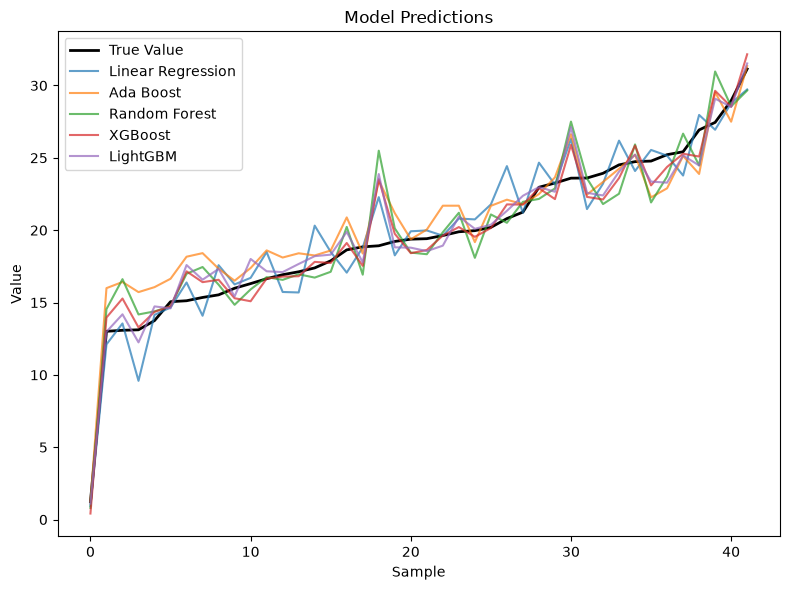

In [13]:
plot_df = pred_table.sort_values('true_val').reset_index(drop=True)

plt.figure(figsize=(8, 6))

plt.plot(plot_df.index, plot_df['true_val'], label='True Value', color='black', linewidth=2)
plt.plot(plot_df.index, plot_df['Linear Regression'], label='Linear Regression', alpha=0.7)
plt.plot(plot_df.index, plot_df['Ada Boost'], label='Ada Boost', alpha=0.7)
plt.plot(plot_df.index, plot_df['Random Forest'], label='Random Forest', alpha=0.7)
plt.plot(plot_df.index, plot_df['XGBoost'], label='XGBoost', alpha=0.7)
plt.plot(plot_df.index, plot_df['LightGBM'], label='LightGBM', alpha=0.7)

plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Model Predictions')
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
del df
gc.collect()
%whos

Variable                         Type                     Data/Info
-------------------------------------------------------------------
AdaBoostRegressor                ABCMeta                  <class 'sklearn.ensemble.<...>sting.AdaBoostRegressor'>
KFold                            ABCMeta                  <class 'sklearn.model_selection._split.KFold'>
LGBMRegressor                    type                     <class 'lightgbm.sklearn.LGBMRegressor'>
LightGBMPruningCallback          type                     <class 'optuna_integratio<...>LightGBMPruningCallback'>
LinearRegression                 ABCMeta                  <class 'sklearn.linear_mo<...>._base.LinearRegression'>
Path                             type                     <class 'pathlib.Path'>
RandomForestRegressor            ABCMeta                  <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
Ridge                            ABCMeta                  <class 'sklearn.linear_model._ridge.Ridge'>
StandardScaler       